# Topical Diversity Identification


The goal of this project stage is to group petitions into thematic clusters (buckets) using NLP to analyze:

- What kinds of topics dominate the platform
- Whether the discussion is diverse or skewed

For this purpose we will use TF-IDF + KMeans clustering.

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import string
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from nltk.corpus import stopwords

## Petition Title Cleaning

In [7]:
df = pd.read_csv("petitions-archive.csv")

# if less than 10 chars we drop
df = df.dropna(subset=["Petition"])
df = df[df["Petition"].str.len() > 10].copy()

#text clean
stop_words = set(stopwords.words("english"))
def clean_text_simple(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)
df["text_clean"] = df["Petition"].apply(clean_text_simple)


# TF-IDF vectorization & clustering

In [8]:
vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, stop_words="english")
X = vectorizer.fit_transform(df["text_clean"])

#kmeans with k=6
num_clusters = 6
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

#shows top words per each cluster
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
#loops for each cluster
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"\nCluster {i} top keywords: {top_terms}")

    cluster_props = df["cluster"].value_counts(normalize=True).sort_index() * 100
print(cluster_props.round(2))


Cluster 0 top keywords: ['school', 'students', 'exams', 'cancel', 'university', 'gcse', 'year', '2021', 'children', 'grades']

Cluster 1 top keywords: ['uk', 'government', 'allow', 'ban', 'make', 'stop', 'citizens', 'covid19', 'lockdown', 'schools']

Cluster 2 top keywords: ['nhs', 'workers', 'staff', 'pay', 'key', 'rise', 'covid19', 'care', 'increase', 'frontline']

Cluster 3 top keywords: ['tax', 'council', 'income', 'workers', 'nhs', 'increase', 'pay', 'covid19', 'key', 'months']

Cluster 4 top keywords: ['make', 'stop', 'ban', 'covid19', 'allow', 'public', 'schools', 'people', 'change', 'covid']

Cluster 5 top keywords: ['health', 'mental', 'care', 'services', 'funding', 'support', 'national', 'workers', 'nhs', 'service']
cluster
0     7.02
1     7.68
2     6.38
3     2.46
4    74.43
5     2.04
Name: proportion, dtype: float64


# Vizualisations

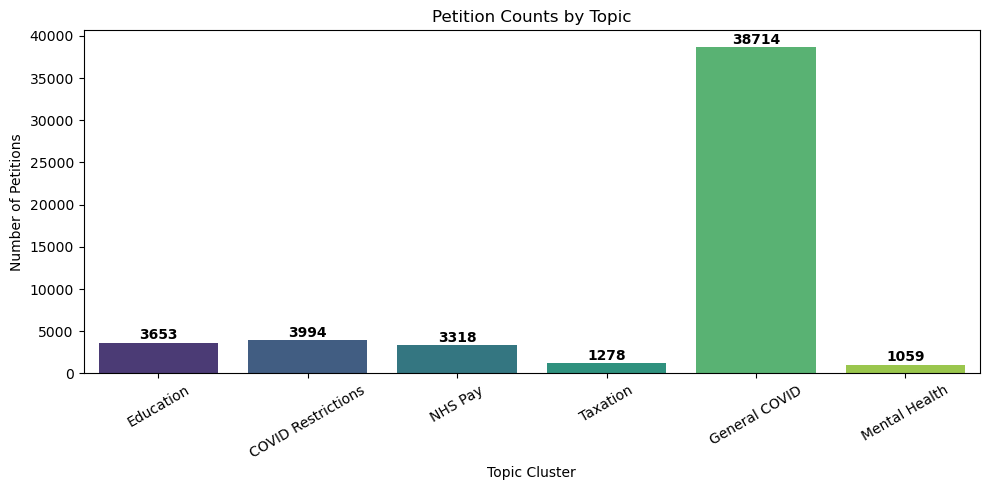

In [9]:
cluster_labels = [
    "Education",
    "COVID Restrictions",
    "NHS Pay",
    "Taxation",
    "General COVID",
    "Mental Health"
]
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=cluster_labels,
    y=cluster_counts.values,
    palette="viridis",
    hue= cluster_labels
)

for i, val in enumerate(cluster_counts.values):
    ax.text(i, val + 20, str(val), ha='center', va='bottom', fontweight='bold')

plt.xlabel("Topic Cluster")
plt.ylabel("Number of Petitions")
plt.title("Petition Counts by Topic")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# A Peek at Petitions per Cluster

In [10]:
pd.set_option("display.max_colwidth", None)

for i in range(6):
    print(f"\nCluster {i} example petitions:")
    print(df[df["cluster"] == i]["Petition"].tail(2).to_string(index=False))



Cluster 0 example petitions:
                                            increase money input to school
Provide a medical assembly to children of age in high school on first aid.

Cluster 1 example petitions:
Remove requirement to register pets as manifest cargo for flights to/from the UK
     Debate the increase of sports subscriptions in the UK, especially football.

Cluster 2 example petitions:
Criminalise smoking on NHS hospital grounds
     Create an NHS staff recruitment agency

Cluster 3 example petitions:
       Abolish or reduce Bedroom tax for people who are trying to downsize.
Update Council Tax Bands to reflect 2024 Household Costs, rather than 1991.

Cluster 4 example petitions:
Put David Attenborough on a bank note
        Get rishi sunak out of office

Cluster 5 example petitions:
                   Not have PIP cut for people with mental health
Fund all health costs for UK nationals who are full-time students


# Live Petitions Dataset Comparison

In [11]:
df_live = pd.read_csv("petitions-live.csv") 
df_live = df_live.dropna(subset=["Petition"])
df_live = df_live[df_live["Petition"].str.len() > 10].copy()

stop_words = set(stopwords.words("english"))

def clean_text_simple(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df_live["text_clean"] = df_live["Petition"].apply(clean_text_simple)

vectorizer_live = TfidfVectorizer(max_df=0.95, min_df=5, stop_words="english")
X_live = vectorizer_live.fit_transform(df_live["text_clean"])

num_clusters_live = 6
kmeans_live = KMeans(n_clusters=num_clusters_live, random_state=42)
df_live["cluster"] = kmeans_live.fit_predict(X_live)

terms_live = vectorizer_live.get_feature_names_out()
order_centroids_live = kmeans_live.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters_live):
    top_terms = [terms_live[ind] for ind in order_centroids_live[i, :10]]
    print(f"\nCluster {i} Top Keywords:", top_terms)

    cluster_props_live = df_live["cluster"].value_counts(normalize=True).sort_index() * 100
print(cluster_props_live.round(2))



Cluster 0 Top Keywords: ['sadiq', 'knighthood', 'khan', 'khans', 'stop', 'sinfield', 'kevin', 'knight', 'getting', 'receiving']

Cluster 1 Top Keywords: ['uk', 'make', 'illegal', 'offence', 'public', 'government', 'gangs', 'grooming', 'mandatory', 'national']

Cluster 2 Top Keywords: ['ban', 'fireworks', 'sale', 'public', 'use', 'uk', 'general', 'products', 'online', 'food']

Cluster 3 Top Keywords: ['create', 'uk', 'efficiency', 'department', 'government', 'scheme', 'public', 'doge', 'national', 'new']

Cluster 4 Top Keywords: ['require', 'review', 'change', 'introduce', 'fund', 'tax', 'allow', 'public', 'national', 'gangs']

Cluster 5 Top Keywords: ['stop', 'pip', 'benefits', 'tax', 'council', 'cuts', 'disabled', 'government', 'uk', 'money']
cluster
0     0.75
1    13.98
2     7.01
3     2.41
4    68.81
5     7.04
Name: proportion, dtype: float64


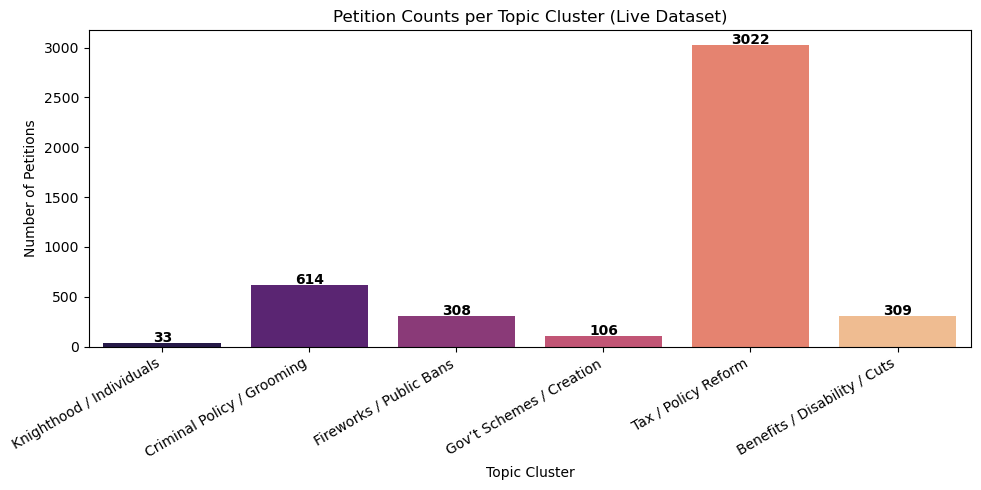

In [12]:
cluster_counts_live = df_live["cluster"].value_counts().sort_index()

cluster_labels_live = [
    "Knighthood / Individuals",
    "Criminal Policy / Grooming",
    "Fireworks / Public Bans",
    "Gov’t Schemes / Creation",
    "Tax / Policy Reform",
    "Benefits / Disability / Cuts"
]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=cluster_labels_live, y=cluster_counts_live.values,
                 hue=cluster_labels_live, palette="magma")

for i, val in enumerate(cluster_counts_live.values):
    ax.text(i, val - 20, str(val), ha='center', va='bottom', fontweight='bold')

plt.xlabel("Topic Cluster")
plt.ylabel("Number of Petitions")
plt.title("Petition Counts per Topic Cluster (Live Dataset)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()